## Datasets

### ICBHI 2017

In [1]:
import os
import glob
import zipfile
import librosa
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import Audio

from torch.utils.data import Dataset

#### Data Loading

Downloading the dataset

In [2]:
data_path = "data/"
dataset1_path = os.path.join(data_path, "ICBHI_final_database")

if not os.path.exists(dataset1_path):
    print("Downloading ICBHI dataset...")
    url = "https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/ICBHI_final_database.zip"
    response = requests.get(url, timeout=30, verify=False)
    response.raise_for_status()

    with open("data/ICBHI_final_database.zip", "wb") as f:
        f.write(response.content)

    print("Extracting ICBHI dataset...")
    with zipfile.ZipFile("data/ICBHI_final_database.zip", "r") as zip_ref:
        zip_ref.extractall(data_path)
print("Done!")

Done!


Downloading extra files that contains demographic informations, diagnosis and training/test splits.

In [3]:
extra_files = [
    "ICBHI_Challenge_demographic_information.txt",
    "ICBHI_Challenge_diagnosis.txt",
    "ICBHI_challenge_train_test.txt",
]

for wav_file_name in extra_files:
    file_path = os.path.join(dataset1_path, wav_file_name)
    if os.path.exists(file_path):
        continue

    print(f"Downloading {wav_file_name}...")
    url = f"https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/{wav_file_name}"
    response = requests.get(url, timeout=30, verify=False)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

print("All required ICBHI files are available.")

All required ICBHI files are available.


#### Audio Sample

Example file path: data/ICBHI_final_database/118_1b1_Ar_sc_Litt3200.wav
Audio shape: (404662,)
Sample rate: 22050
Duration: 18.35 seconds


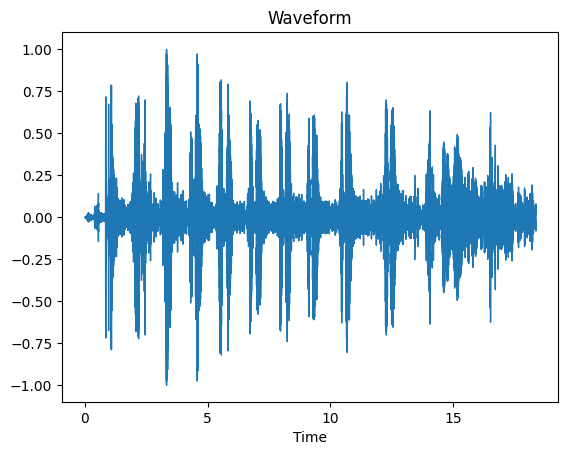

In [ ]:
# Load a random audio file from the dataset
wav_files = glob.glob(os.path.join(dataset1_path, "**/*.wav"), recursive=True)
filename = np.random.choice(wav_files)
print(f"Example file path: {filename}")

# Load the audio file
audio, sr = librosa.load(filename)
print(f"Audio shape: {audio.shape}")
print(f"Sample rate: {sr}")
print(f"Duration: {len(audio) / sr:.2f} seconds")

# Plot the audio waveform
librosa.display.waveshow(audio, sr=sr)
plt.title('Waveform')
plt.show()

# Play the audio
Audio(data=audio, rate=sr)

#### LungSound class

In [5]:
class LungSound():
    """
    Class to represent a lung sound recording and its associated metadata.
    """
    def __init__(self, file_path):
        self.wav_file = file_path
        self.text_file = file_path.replace(".wav", ".txt")
        self._load_audio()
        self._load_annotations()

    def _load_audio(self):
        # Load the audio file
        self.audio, self.sr = librosa.load(self.wav_file)

    def _load_annotations(self):
        # Load the annotation file
        columns = ["StartTime", "EndTime", "Crackle", "Wheeze"]
        self.annotations = pd.read_csv(self.text_file, names=columns, delimiter= '\t')

    def get_metadata(self):
        wav_file_name = os.path.basename(self.wav_file)
        parts = wav_file_name.split("_")
        return {
            "FileName": wav_file_name.split(".")[0],  # Remove file extension
            "PatientNumber": parts[0],
            "RecordingIndex": parts[1],
            "ChestLocation": parts[2],
            "AcquisitionMode": parts[3],
            "RecordingEquipment": parts[4].split(".")[0]  # Remove file extension
        }

    def plot_waveform(self, title=None, ax=None):
        # Plot the audio waveform
        if title is None:
            title = f"{self.get_metadata()['FileName']}"
        if ax is None:
            librosa.display.waveshow(self.audio, sr=self.sr)
            plt.title(f"{title}")
            plt.show()
        else:
            librosa.display.waveshow(self.audio, sr=self.sr, ax=ax)
            ax.set_title(f"{title}")

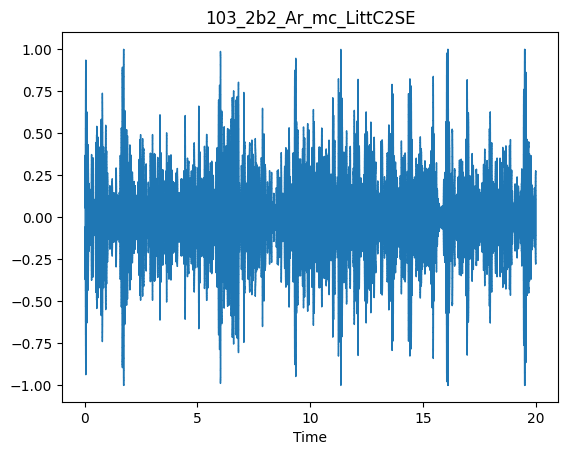

,StartTime,EndTime,Crackle,Wheeze
0,0.364,3.250,0,1
1,3.250,6.636,0,0
2,6.636,11.179,0,1
3,11.179,14.250,0,1
4,14.250,16.993,0,1
5,16.993,19.979,0,0


In [6]:
filename = os.path.join(dataset1_path, "103_2b2_Ar_mc_LittC2SE.wav")
lung_sound = LungSound(filename)
lung_sound.plot_waveform()
display(lung_sound.annotations)
Audio(data=lung_sound.audio, rate=lung_sound.sr)

#### Spectrograms

Spectrogram shape: (1025, 862)


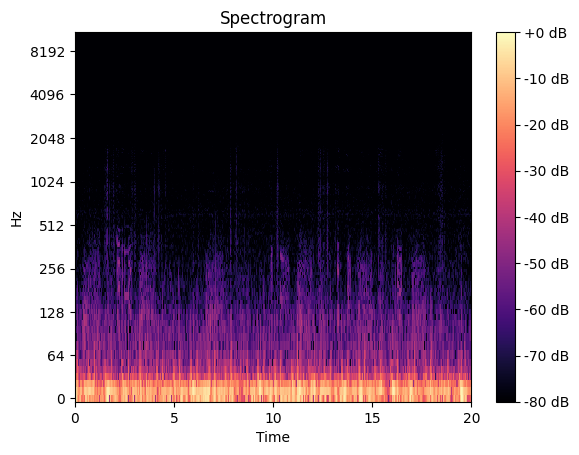

In [7]:
# Compute Short-Time Fourier Transform (STFT)
stft = librosa.stft(lung_sound.audio)
# Compute the magnitude of the STFT to get the spectrogram
spectrogram = np.abs(stft)
# Convert the amplitude spectrogram to decibel (dB) units
spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
# Display the spectrogram
print(f"Spectrogram shape: {spectrogram_db.shape}")
librosa.display.specshow(spectrogram_db, sr=lung_sound.sr, x_axis='time', y_axis='log')
plt.title('Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.show()

Mel Spectrogram shape: (128, 862)


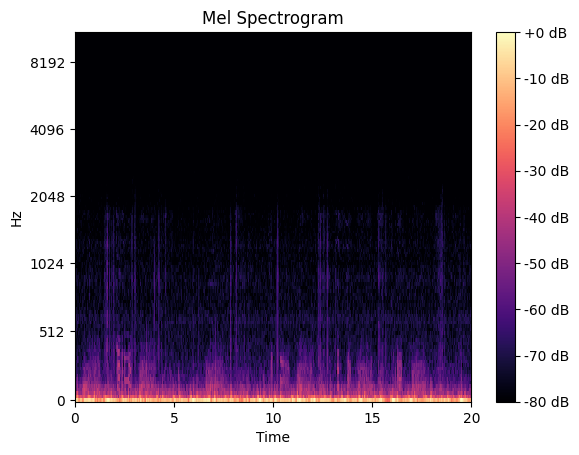

In [8]:
# Compute the Mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=lung_sound.audio, sr=lung_sound.sr)
# Convert the Mel spectrogram to decibel (dB) units
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
# Display the Mel spectrogram
print(f"Mel Spectrogram shape: {mel_spectrogram_db.shape}")
librosa.display.specshow(mel_spectrogram_db, sr=lung_sound.sr, x_axis='time', y_axis='mel')
plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

MFCCs shape: (20, 862)


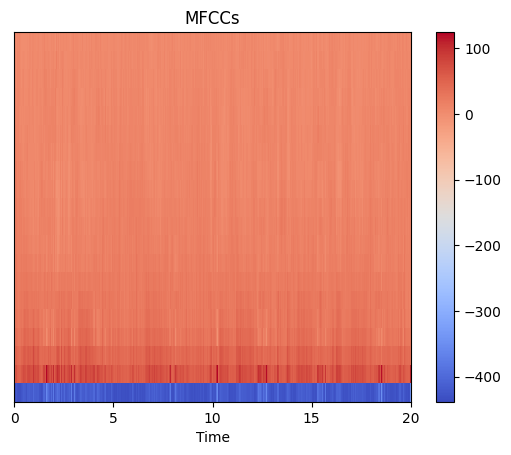

In [9]:
# Compute the MFCCs
mfccs = librosa.feature.mfcc(y=lung_sound.audio, sr=lung_sound.sr)
# Display the MFCCs
print(f"MFCCs shape: {mfccs.shape}")
librosa.display.specshow(mfccs, sr=lung_sound.sr, x_axis='time')
plt.title('MFCCs')
plt.colorbar()
plt.show()

#### Dataset class

In [10]:
class ICBHIDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self._load_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.data.iloc[idx]["WavFile"])
        audio = LungSound(file_path)
        label = self.data.iloc[idx]["Diagnosis"]
        return audio, label

    def _load_data(self):
        data = []
        annot = []
        for file in sorted(glob.glob(os.path.join(self.data_dir, "*.wav"))):
            wav_file = os.path.basename(file)
            text_file = os.path.splitext(file)[0] + ".txt"
            data.append(wav_file)
            annot.append(self.extract_metadata(text_file))

        diagnosis_file = os.path.join(self.data_dir, "ICBHI_Challenge_diagnosis.txt")
        diagnosis_df = pd.read_csv(
            diagnosis_file, names=["PatientNumber", "Diagnosis"], delimiter='\t',
            dtype={"PatientNumber": str, "Diagnosis": str}
        )
        data = pd.DataFrame({"WavFile": data})
        annot = pd.DataFrame(annot)
        self.data = pd.concat([data, annot], axis=1)
        self.data = self.data.merge(diagnosis_df, on="PatientNumber", how="left")

    def unit_test(self, idx=0):
        # Test loading a sample
        sample, label = self[idx]
        print(f"Sample: {sample.audio.shape} {sample.sr}")
        sample.plot_waveform(title=f"Diagnosis: {label}")
        display(sample.annotations)
        return sample

    @ staticmethod
    def extract_metadata(file_path):
        wav_file_name = os.path.basename(file_path)
        parts = wav_file_name.split("_")
        return {
            "FileName": wav_file_name,
            "PatientNumber": parts[0],
            "RecordingIndex": parts[1],
            "ChestLocation": parts[2],
            "AcquisitionMode": parts[3],
            "RecordingEquipment": parts[4].split(".")[0]  # Remove file extension
        }

In [11]:
dataset = ICBHIDataset(dataset1_path)
print(f"Dataset size: {len(dataset)} samples")
dataset.data.head()

Dataset size: 920 samples


,WavFile,FileName,PatientNumber,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Diagnosis
0,101_1b1_Al_sc_Meditron.wav,101_1b1_Al_sc_Meditron.txt,101,1b1,Al,sc,Meditron,URTI
1,101_1b1_Pr_sc_Meditron.wav,101_1b1_Pr_sc_Meditron.txt,101,1b1,Pr,sc,Meditron,URTI
2,102_1b1_Ar_sc_Meditron.wav,102_1b1_Ar_sc_Meditron.txt,102,1b1,Ar,sc,Meditron,Healthy
3,103_2b2_Ar_mc_LittC2SE.wav,103_2b2_Ar_mc_LittC2SE.txt,103,2b2,Ar,mc,LittC2SE,Asthma
4,104_1b1_Al_sc_Litt3200.wav,104_1b1_Al_sc_Litt3200.txt,104,1b1,Al,sc,Litt3200,COPD


#### Class distribution

Diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


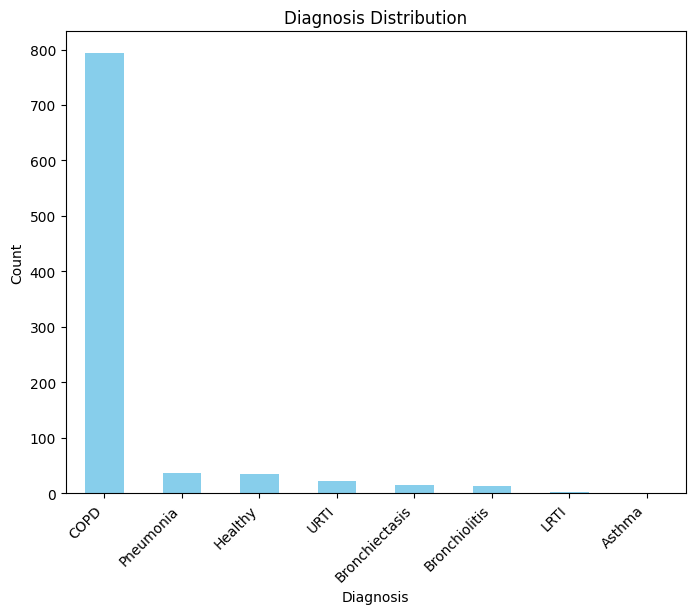

In [12]:
# Plot diagnosis distribution
diagnosis_counts = dataset.data['Diagnosis'].value_counts()
print(diagnosis_counts)
plt.figure(figsize=(8, 6))
# show number in bars
diagnosis_counts.plot(kind='bar', color='skyblue')
plt.title('Diagnosis Distribution')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.show()

Sample: (714420,) 22050


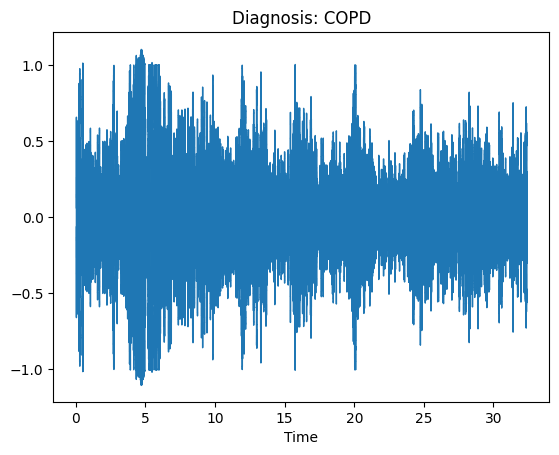

,StartTime,EndTime,Crackle,Wheeze
0,3.6457,7.601,0,1
1,7.6010,11.667,0,1
2,11.6670,15.441,0,0
3,15.4410,19.678,0,0
4,19.6780,23.855,0,1
5,23.8550,28.052,0,0
6,28.0520,32.400,0,0


In [14]:
sample = dataset.unit_test(idx=50)